In [167]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import pickle 
import scipy
import time as tim

from neuromancer.psl import plot
from neuromancer import psl
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from neuromancer.system import Node, System
from neuromancer.slim import slim
from neuromancer.trainer import Trainer
from neuromancer.problem import Problem
from neuromancer.dataset import DictDataset
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer. modules import blocks
import joblib

from sklearn.preprocessing import StandardScaler
torch.manual_seed(0)


In [168]:
from scipy.io import loadmat
import os

# Base directory where sem2025 data lives
SEM2025_DIR = os.path.join('..', 'NewALL')

# Load original raw data for scaler fitting
raw_data = loadmat(os.path.join(SEM2025_DIR, 'identifikacia2.mat'))

# Load step response data
test_data = loadmat(os.path.join(SEM2025_DIR, 'test_data.mat'))
train_data = loadmat(os.path.join(SEM2025_DIR, 'train_data.mat'))


c:\Users\ivadu\Desktop\9.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\koopman_py311\Lib\site-packages\scipy\io\matlab\_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


In [169]:
def get_data(train_sim, test_sim, nx, nu, nsteps, bs, scaler, scalerU):
    dev_sim = train_sim

    # Combine training and test data for reshaping
    trainY = np.vstack((train_sim['Y'], test_sim['Y']))
    trainU = np.vstack((train_sim['U'], test_sim['U']))#cely dataset

    nsim = trainY.shape[0]
    nbatch = nsim // nsteps
    length = nbatch * nsteps

    trainX = scaler.transform(trainY[:length]).reshape(nbatch, nsteps, nx)
    trainU = scalerU.transform(trainU[:length]).reshape(nbatch, nsteps, nu)

    train_dataset = DictDataset({
        'Y': torch.tensor(trainX, dtype=torch.float32),
        'Y0': torch.tensor(trainX[:, 0:1, :], dtype=torch.float32),
        'U': torch.tensor(trainU, dtype=torch.float32)
    }, name='train')

    train_loader = DataLoader(train_dataset, batch_size=bs,
                              collate_fn=train_dataset.collate_fn, shuffle=True)

    # Dev set
    nsim = dev_sim['Y'].shape[0]
    nbatch = nsim // nsteps
    length = nbatch * nsteps

    devX = scaler.transform(dev_sim['Y'][:length]).reshape(nbatch, nsteps, nx)
    devU = scalerU.transform(dev_sim['U'][:length]).reshape(nbatch, nsteps, nu)

    dev_dataset = DictDataset({
        'Y': torch.tensor(devX, dtype=torch.float32),
        'Y0': torch.tensor(devX[:, 0:1, :], dtype=torch.float32),
        'U': torch.tensor(devU, dtype=torch.float32)
    }, name='dev')

    dev_loader = DataLoader(dev_dataset, batch_size=bs,
                            collate_fn=dev_dataset.collate_fn, shuffle=True)

    # Test set (single trajectory)
    nsim = test_sim['Y'].shape[0]
    nbatch = nsim // nsteps
    length = nbatch * nsteps

    testX = scaler.transform(test_sim['Y'][:length]).reshape(1, nbatch * nsteps, nx)
    testU = scalerU.transform(test_sim['U'][:length]).reshape(1, nbatch * nsteps, nu)

    test_dataset = {
        'Y': torch.tensor(testX, dtype=torch.float32),
        'Y0': torch.tensor(testX[:, 0:1, :], dtype=torch.float32),
        'U': torch.tensor(testU, dtype=torch.float32)
    }

    return train_loader, dev_loader, test_dataset


In [170]:
nsteps = 50   # number of prediction horizon steps in the loss function
bs = 100      # minibatching batch size

Y_full = np.vstack((train_data['Ytrain'], test_data['Ytest']))
U_full = np.vstack((train_data['Utrain'], test_data['Utest']))

train_sim = {
    'Y': Y_full,
    'U': U_full
}
test_sim = {
    'Y': Y_full,
    'U': U_full
}
nsim = train_sim['Y'].shape[0]   # number of simulation steps in the dataset

# Create and fit scalers
#scaler = StandardScaler()
#scalerU = StandardScaler()

# Load scalers
scaler = joblib.load('data/scaler.pkl')
scalerU = joblib.load('data/scalerU.pkl')

# Fit scalers on ALL step response data (train + test)
#Y_all = np.vstack((train_data['Ytrain'], test_data['Ytest']))
#U_all = np.vstack((train_data['Utrain'], test_data['Utest']))

#scaler.fit(Y_all)
#scalerU.fit(U_all)

# Create data directory if it doesn't exist
#os.makedirs(os.path.join(SEM2025_DIR, 'data'), exist_ok=True)

# Save scalers
#joblib.dump(scaler, os.path.join(SEM2025_DIR, 'data', 'scaler.pkl'))
#joblib.dump(scalerU, os.path.join(SEM2025_DIR, 'data', 'scalerU.pkl'))

nx = train_sim['Y'].shape[1]
ny = train_sim['Y'].shape[1]
nu = train_sim['U'].shape[1]

train_loader, dev_loader, test_data = get_data(
    train_sim, test_sim, nx, nu, nsteps, bs, scaler, scalerU
)


In [171]:
print("Python scaler mean (x):", scaler.mean_[0])
print("Python scaler std (x):", scaler.scale_[0])
print("Python scaler mean (u):", scalerU.mean_[0])
print("Python scaler std (u):", scalerU.scale_[0])

print("\nMATLAB values:")
print("y_mean = 58.3377")
print("y_std = 7.1204") 
print("u_mean = 63.0883")
print("u_std = 23.9910")




Python scaler mean (x): 58.337700739046234
Python scaler std (x): 7.119317273516296
Python scaler mean (u): 63.08828052906798
Python scaler std (u): 23.987293259622874

MATLAB values:
y_mean = 58.3377
y_std = 7.1204
u_mean = 63.0883
u_std = 23.9910


In [ ]:
# Debug: Check what keys are in test_data
print("Keys in test_data:", test_data.keys())
print("Shape of test_data['Y']:", test_data['Y'].shape)
print("Shape of test_data['U']:", test_data['U'].shape)


In [ ]:
# Fix test_data structure - add Y0 if missing
if 'Y0' not in test_data:
    test_data['Y0'] = test_data['Y'][:, 0:1, :]  # First timestep of Y
    print("Added Y0 to test_data")
    
print("Updated keys in test_data:", test_data.keys())
print("Shape of test_data['Y0']:", test_data['Y0'].shape)


In [172]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import pickle 
import scipy
import time as tim

from neuromancer.psl import plot
from neuromancer import psl
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from neuromancer.system import Node, System
from neuromancer.slim import slim
from neuromancer.trainer import Trainer
from neuromancer.problem import Problem
from neuromancer.dataset import DictDataset
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer. modules import blocks
import joblib

from sklearn.preprocessing import StandardScaler
torch.manual_seed(0)

## Generate trajectories from ODE system 

In this example we don't assume any prior knowledge on the system dynamics. We will only have access to limited measurements of the system states $x$ of an unknown [ordinary differential equations](https://en.wikipedia.org/wiki/Ordinary_differential_equation) (ODE).

Select the system_name from the available list of [nonautonomous ODE systems](https://github.com/pnnl/neuromancer/blob/master/src/neuromancer/psl/nonautonomous.py):
- TwoTank
- CSTR
- SwingEquation
- IverSimple

# Get and save data - (Already done)

## Create training data of sampled trajectories

We will obtain a dataset of sampled trajectories of the system dynamics in the form of input-state tuples: 
$$D = \big[(u^i_0, \hat{x}^i_0), ..., (u^i_N, \hat{x}^i_{N}) \big], \, \, i \in [1, ..., m]$$
where $N$ represents the prediction horizon, $m$ represents number of measured trajectories, and $i$ represents an index of the sampled trajectory.
Variables $x_k$ represent system states, and $u_k$ are exogenous inputs at time $k$.

In [173]:
# with open('data/train_real.pkl', 'rb') as fp:
#         train_sim = pickle.load(fp)

# with open('data/test_real.pkl', 'rb') as fp:
#         test_sim = pickle.load(fp)

In [174]:
from scipy.io import loadmat
import os

""" #data = loadmat('data.mat')"""

# Base directory where sem2025 data lives
SEM2025_DIR = os.path.join('..', 'NewALL')

test_data = loadmat(os.path.join(SEM2025_DIR, 'test_data.mat'))
train_data = loadmat(os.path.join(SEM2025_DIR, 'train_data.mat'))

"""
# Explore the content


print(train_data['Utrain'].shape)
print(train_data['Ytrain'].shape)

print(test_data['Utest'].shape)
print(test_data['Ytest'].shape) """

""" print(test_data['U'].shape)
print(test_data['Y'].shape)
print(test_data['X'].shape)
print(test_data['U'].shape) """
""" 
print(data['U'].shape)
print(data.keys())
print(data['U'].shape) """

" \nprint(data['U'].shape)\nprint(data.keys())\nprint(data['U'].shape) "

In [175]:

def get_data(train_sim, test_sim, nx, nu, nsteps, bs, scaler, scalerU):
    dev_sim = train_sim

    # Combine training and test data for reshaping
    trainY = np.vstack((train_sim['Y'], test_sim['Y']))
    trainU = np.vstack((train_sim['U'], test_sim['U']))#cely dataset

    nsim = trainY.shape[0]
    nbatch = nsim // nsteps
    length = nbatch * nsteps

    trainX = scaler.transform(trainY[:length]).reshape(nbatch, nsteps, nx)
    trainU = scalerU.transform(trainU[:length]).reshape(nbatch, nsteps, nu)

    train_dataset = DictDataset({
        'Y': torch.tensor(trainX, dtype=torch.float32),
        'Y0': torch.tensor(trainX[:, 0:1, :], dtype=torch.float32),
        'U': torch.tensor(trainU, dtype=torch.float32)
    }, name='train')

    train_loader = DataLoader(train_dataset, batch_size=bs,
                              collate_fn=train_dataset.collate_fn, shuffle=True)

    # Dev set
    nsim = dev_sim['Y'].shape[0]
    nbatch = nsim // nsteps
    length = nbatch * nsteps

    devX = scaler.transform(dev_sim['Y'][:length]).reshape(nbatch, nsteps, nx)
    devU = scalerU.transform(dev_sim['U'][:length]).reshape(nbatch, nsteps, nu)

    dev_dataset = DictDataset({
        'Y': torch.tensor(devX, dtype=torch.float32),
        'Y0': torch.tensor(devX[:, 0:1, :], dtype=torch.float32),
        'U': torch.tensor(devU, dtype=torch.float32)
    }, name='dev')

    dev_loader = DataLoader(dev_dataset, batch_size=bs,
                            collate_fn=dev_dataset.collate_fn, shuffle=True)

    # Test set (single trajectory)
    nsim = test_sim['Y'].shape[0]
    nbatch = nsim // nsteps
    length = nbatch * nsteps

    testX = scaler.transform(test_sim['Y'][:length]).reshape(1, nbatch * nsteps, nx)
    testU = scalerU.transform(test_sim['U'][:length]).reshape(1, nbatch * nsteps, nu)

    test_dataset = {
        'Y': torch.tensor(testX, dtype=torch.float32),
        'Y0': torch.tensor(testX[:, 0:1, :], dtype=torch.float32),
        'U': torch.tensor(testU, dtype=torch.float32)
    }

    return train_loader, dev_loader, test_dataset


In [176]:
print("New scaler mean (x):", scaler.mean_[0])
print("New scaler std (x):", scaler.scale_[0])
print("New scaler mean (u):", scalerU.mean_[0])
print("New scaler std (u):", scalerU.scale_[0])

New scaler mean (x): 58.337700739046234
New scaler std (x): 7.119317273516296
New scaler mean (u): 63.08828052906798
New scaler std (u): 23.987293259622874


In [177]:
scaler.inverse_transform([[0]])

array([[58.33770074]])

In [178]:

print("Mean:", scaler.mean_[0])           # The mean value for each feature
print("Scale (std dev):", scaler.scale_)  # The standard deviation for each feature
print("Var:", scaler.var_)      

Mean: 58.337700739046234
Scale (std dev): [7.11931727]
Var: [50.68467844]


In [179]:

print("Mean:", scalerU.mean_)            # The mean value for each feature
print("Scale (std dev):", scalerU.scale_)  # The standard deviation for each feature
print("Var:", scalerU.var_)      

Mean: [63.08828053]
Scale (std dev): [23.98729326]
Var: [575.39023792]


## Deep Koopman model in Neuromancer

Here we construct a discrete-time encoder-decoder Koopman model with control:   

<img src="../figs/Koopman_model.png" width="500">  


Encoder: $${x}_{k} = f_y(y_k) +f_u(u_k)$$ 
Koopman: $${x}_{k+1} = K(x_k)$$ 
Decoder: $$\hat{y}_{k+1} = f_y^{-1}(x_{k+1})$$  

In [180]:
# model parameters
nx_koopman = 10#stavy systemu - kolko Z - k comu skonvergujeme
nx_koopman_baseline = 80
# n_hidden = 32
# n_layers = 2
layers = [60,60,60]
layers_baseline = [60,60,60]

**Encoder and Decoder networks** 

In [181]:
# instantiate output encoder neural net f_y
f_y = blocks.MLP( #g(x)
    ny,
    nx_koopman,
    bias=True,
    linear_map=torch.nn.Linear,
    nonlin=torch.nn.ReLU,
    hsizes=layers,
)
# initial condition encoder
encode_Y0 = Node(f_y, ['Y0'], ['x'], name='encoder_Y0') #nn
# observed trajectory encoder
encode_Y = Node(f_y, ['Y'], ['x_latent'], name='encoder_Y')

#x,x_latenet

In [182]:
# instantiate input encoder net f_u

f_u = torch.nn.Linear(nu, nx_koopman, bias=False)
# initial condition encoder
encode_U = Node(f_u, ['U'], ['u_latent'], name='encoder_U')

In [183]:
# instantiate state decoder neural net f_y_inv
# f_y_inv = blocks.MLP(nx_koopman, ny, bias=True,
#                 linear_map=torch.nn.Linear,
#                 nonlin=torch.nn.ELU,
#                 hsizes=n_layers*[n_hidden])
f_y_inv = torch.nn.Linear(nx_koopman, ny, bias=False)
# predicted trajectory decoder
decode_y = Node(f_y_inv, ['x'], ['yhat'], name='decoder_y')

In [184]:
f_y_baseline = blocks.MLP(
    ny,
    nx_koopman_baseline,
    bias=True,
    linear_map=torch.nn.Linear,
    nonlin=torch.nn.ReLU,
    hsizes=layers_baseline,
)
# initial condition encoder
encode_Y0_baseline = Node(f_y_baseline, ['Y0'], ['x'], name='encoder_Y0')
# observed trajectory encoder
encode_Y_baseline = Node(f_y_baseline, ['Y'], ['x_latent'], name='encoder_Y')

f_u_baseline = torch.nn.Linear(nu, nx_koopman_baseline, bias=False)
# initial condition encoder
encode_U_baseline = Node(f_u_baseline, ['U'], ['u_latent'], name='encoder_U')
# instantiate state decoder neural net f_y_inv
f_y_inv_baseline = blocks.MLP(nx_koopman_baseline, ny, bias=True,
                linear_map=torch.nn.Linear,
                nonlin=torch.nn.ELU,
                hsizes=layers_baseline)
# f_y_inv = torch.nn.Linear(nx_koopman, ny, bias=False)
# predicted trajectory decoder
decode_y_baseline = Node(f_y_inv_baseline, ['x'], ['yhat'], name='decoder_y')

**Standard Koopman Operator** without stability guarantees is parametrized by linear layer of the latent size. 

**Stable Koopman Operator:**  For provably stable Koopman operator we can choose a range of linear algebra factorization that allow to constrain the eigenvalues of the resulting linear operator. 
In this example we use the following [Singular Value Decomposition (SVD)](https://en.wikipedia.org/wiki/Singular_value_decomposition) factorization of the operator given as:
$$K = U \Sigma V$$ 
$$\Sigma =  \text{diag}(\lambda_{\text{max}} - (\lambda_{\text{max}} - \lambda_{\text{min}}) \cdot \sigma(\Lambda)) $$
where $\sigma$ is logistic sigmoid activation function, $\cdot$ is a dot product, $\Lambda$ is a vector of eigenvalues of the linear operator, while $\lambda_{\text{max}}$ and $\lambda_{\text{min}}$ are constraints on maximum and minimum value of SVD factorized linear operator.

<img src="../figs/SVD_layer.png" width="300">  

In order for the SVD factorization to hold the left and right matrices $U$ and $V$, respectively, needs to be [orthogonal](https://en.wikipedia.org/wiki/Orthogonal_matrix).
This can be achieved either via [Householder reflectors](https://arxiv.org/abs/1803.09327), or via penalties in the loss function given as:  
$$\ell_{U} = || I - UU^T||_2 + || I - U^TU||_2  $$
$$\ell_{V} = || I - VV^T||_2 + || I - V^TV||_2  $$
$$\ell_{\text{stable}} = \ell_{U} + \ell_{V} $$

For more details on the SVD and other linear algebra factorizations of trainable linear layers see the references [[7]](https://ieeexplore.ieee.org/document/9482930) and [[8]](https://ieeexplore.ieee.org/abstract/document/9809789), with Pytorch implementations in the [slim submodule](https://github.com/pnnl/neuromancer/tree/master/src/neuromancer/slim) of the Neuromancer library. 

In [185]:
# instantiate Koopman operator matrix
stable = False     # if True then provably stable Koopman operator
if stable:
    # SVD factorized Koopman operator with bounded eigenvalues: sigma_min <= \lambda_i <= sigma_max
    K = slim.linear.SVDLinear(nx_koopman, nx_koopman,
                          sigma_min=0.01, sigma_max=1.0, bias=False)
    # SVD penalty variable
    K_reg_error = variable(K.reg_error())
    # SVD penalty loss term
    K_reg_loss = 1.*(K_reg_error == 0.0)
    K_reg_loss.name = 'SVD_loss'
else:
    # linear Koopman operator without guaranteed stability
    K = torch.nn.Linear(nx_koopman, nx_koopman, bias=False)
    K_baseline = torch.nn.Linear(nx_koopman_baseline, nx_koopman_baseline, bias=False)

In [186]:
class Koopman_control(nn.Module):
    """
    Baseline class for Koopman control model
    Implements discrete-time dynamical system:
        x_k+1 = K x_k + u_k
    with variables:
        x_k - latent states
        u_k - latent control inputs
    """

    def __init__(self, K):
        super().__init__()
        self.K = K

    def forward(self, x, u):
        """
        :param x: (torch.Tensor, shape=[batchsize, nx])
        :param u: (torch.Tensor, shape=[batchsize, nx])
        :return: (torch.Tensor, shape=[batchsize, nx])
        """
        x = self.K(x) + u
        return x

In [187]:
# symbolic Koopman model with control inputs
Koopman = Node(Koopman_control(K), ['x', 'u_latent'], ['x'], name='K')
Koopman_baseline = Node(Koopman_control(K_baseline), ['x', 'u_latent'], ['x'], name='K')

# latent Koopmann rollout
dynamics_model = System([Koopman], name='Koopman', nsteps=nsteps)
dynamics_model_baseline = System([Koopman_baseline], name='Koopman', nsteps=nsteps)

In [188]:
# put all nodes of the Koopman model together in a list of nodes
nodes = [encode_Y0, encode_Y, encode_U, dynamics_model, decode_y]

nodes_baseline = [encode_Y0_baseline, encode_Y_baseline, encode_U_baseline, dynamics_model_baseline, decode_y_baseline]

## Define Koopman system identification loss function terms

Here we define loss function terms to fit the encoded-decoder Koopman parameters $\theta$ from given time-series data.
The loss function terms follow the implementation as given in the reference [[2]](https://www.nature.com/articles/s41467-018-07210-0). 

**Output trajectory prediction loss:**  
$$\ell_y = \sum_{k=1}^{N} Q_y||y^i_{k+1} - \hat{y}^i_{k+1}||_2^2$$ 
**One step output prediction loss:**  
$$\ell_{y_1} = Q_{y_1}||y^i_2 - \hat{y}^i_2||_2^2$$ 

where $\hat{y}^i_{k+1} = \phi^{-1}_{\theta_3}(K^k_{\theta_2}(\phi_{\theta_1}(y^i_1))) $, 
and $N$ is defining length of the rollout (prediction) horizon.  

**Latent trajectory prediction loss:**  
$$\ell_{\text{lin}} = \sum_{k=1}^{N}  Q_x||\phi_{\theta_1}(y_{k+1}^i) - K^k\phi_{\theta_1}(y_1^i)||_2^2$$ 


In [189]:
# variables
Y = variable("Y")  # observed
yhat = variable('yhat')  # predicted output
x_latent = variable('x_latent')  # encoded output trajectory in the latent space
u_latent = variable('u_latent')  # encoded input trajectory in the latent space
x = variable('x')  # Koopman latent space trajectory

xu_latent = x_latent + u_latent  # latent state trajectory

# output trajectory tracking loss
y_loss = 10. * (yhat[:, 1:-1, :] == Y[:, 1:, :]) ^ 2
y_loss.name = "y_loss"

# one-step tracking loss
onestep_loss = 1.*(yhat[:, 1, :] == Y[:, 1, :])^2
onestep_loss.name = "onestep_loss"

# reconstruction loss
reconstruction_loss = 20.*(yhat[:, 0, :] == Y[:, 0, :])^2
reconstruction_loss.name = "reconstruction_loss"


# latent trajectory tracking loss
x_loss = 1. * (x[:, 1:-1, :] == xu_latent[:, 1:, :]) ^ 2
x_loss.name = "x_loss"


## Construct System ID learning problem

Given the training dataset $\hat{X} = [\hat{x}^i_0, ..., \hat{x}^i_{N}]$ we want to solve the following problem:
 
$$
\begin{align}
&\underset{\theta}{\text{minimize}}     && \sum_{i=1}^m \Big( \ell_{y} + \ell_{y_1}  +\ell_{\text{lin}} + \ell_{\text{recon}} + \ell_{\text{stable}} \Big) \\
&\text{subject to}    && \hat{y}^i_{k+1} = \phi^{-1}_{\theta_3}(K^k_{\theta_2}(\phi_{\theta_1}(y_1^i))) \\
\end{align}
$$  

In [190]:
# aggregate list of objective terms and constraints
objectives = [y_loss, x_loss, onestep_loss, reconstruction_loss]

if stable:
    objectives.append(K_reg_loss)

# create constrained optimization loss
loss = PenaltyLoss(objectives, constraints=[])

# construct constrained optimization problem
problem = Problem(nodes, loss)

problem_baseline = Problem(nodes_baseline, loss)

In [191]:
#problem_baseline.load_state_dict(torch.load('data/model_baseline.pth'),strict=False)

In [192]:
# plot computational graph
#problem.show()
print(problem.input_keys)
print(problem.output_keys)

['Y0', 'yhat', 'U', 'Y', 'x', 'u_latent', 'x_latent']
['C_values', 'C_eq_values', 'objective_loss', 'C_ineq_violations', 'loss', 'yhat', 'penalty_loss', 'C_ineq_values', 'C_eq_violations', 'x', 'C_violations', 'u_latent', 'x_latent']


## Solve the problem

We fit the unknown NODE parameters $\theta$ using stochastic gradient descent.

In [193]:
optimizer = torch.optim.Adam(problem.parameters(), lr=0.001)

trainer = Trainer(
    problem,
    train_loader,
    dev_loader,
    test_data,
    optimizer,
    patience=200,
    warmup=100,
    epochs=900,
    eval_metric="dev_loss",
    train_metric="train_loss",
    dev_metric="dev_loss",
    test_metric="dev_loss",
)


In [194]:
# %% train
start = tim.time()
best_model = trainer.train()
problem.load_state_dict(best_model)
end = tim.time()


epoch: 0  train_loss: 28.959617614746094


epoch: 1  train_loss: 27.695632934570312
epoch: 2  train_loss: 27.210325241088867
epoch: 3  train_loss: 24.597265243530273
epoch: 4  train_loss: 23.914228439331055
epoch: 5  train_loss: 21.601287841796875
epoch: 6  train_loss: 21.451282501220703
epoch: 7  train_loss: 18.92632293701172
epoch: 8  train_loss: 16.57097625732422
epoch: 9  train_loss: 15.126801490783691
epoch: 10  train_loss: 12.31930923461914
epoch: 11  train_loss: 10.711458206176758
epoch: 12  train_loss: 7.719479560852051
epoch: 13  train_loss: 6.626413345336914
epoch: 14  train_loss: 5.328750133514404
epoch: 15  train_loss: 4.653753757476807
epoch: 16  train_loss: 4.2809906005859375
epoch: 17  train_loss: 4.472734451293945
epoch: 18  train_loss: 4.483638763427734
epoch: 19  train_loss: 4.350037574768066
epoch: 20  train_loss: 4.242908954620361
epoch: 21  train_loss: 3.6993870735168457
epoch: 22  train_loss: 3.5416128635406494
epoch: 23  train_loss: 3.4234461784362793
epoch: 24  train_loss: 3.472464084625244
epoch: 25  tr

In [195]:
#torch.save(best_model, "./data/model_" + timestamp_str + ".pth")
""" torch.save(best_model, "./data/modelC.pth") """

' torch.save(best_model, "./data/modelC.pth") '

In [196]:
# # load problem
#problem.load_state_dict(torch.load('./data/modelC.pth'),strict=False)

In [197]:
# elapsed time
# print(f"Elapsed time train: {end-start:.2f} sec")


## System Identification results

In [198]:
problem.nodes

ModuleList(
  (0): encoder_Y0(Y0) -> x
  (1): encoder_Y(Y) -> x_latent
  (2): encoder_U(U) -> u_latent
  (3): System(
    (nodes): ModuleList(
      (0): K(x, u_latent) -> x
    )
  )
  (4): decoder_y(x) -> yhat
)

In [199]:
# update the rollout length based on the test data
problem.nodes[3].nsteps = 2000

In [200]:
# Test set results



start = tim.time()
test_outputs = problem.step(test_data)
end = tim.time()
print(f"Elapsed time test: {end-start:.2f} sec")

pred_traj = test_outputs['yhat'][:, 1:-1, :].detach().numpy().reshape(-1, nx).T
true_traj = test_data['Y'][:, 1:pred_traj.shape[1]+1, ].detach().numpy().reshape(-1, nx).T
input_traj = test_data['U'].detach().numpy().reshape(-1, nu).T

KeyError: 'Y0'

In [ ]:
problem_baseline.nodes[3].nsteps = 2000

start = tim.time()
test_outputs = problem_baseline.step(test_data)
end = tim.time()
print(f"Elapsed time test: {end-start:.2f} sec")

baseline_y = test_outputs['yhat'][:, 1:-1, :].detach().numpy().reshape(-1, nx).T

Elapsed time test: 0.26 sec


In [ ]:
np.mean((pred_traj - true_traj) ** 2)
#2*60; 40 0.06774564
#3*60 80 0.05942205
# 16 32 64 40 0.06478106
# 16 32 64 64 0.06103883
# 16 32 64 128 0.07568752
# 32 64 128 128 0.061701212


0.14719377

In [ ]:
from scipy.signal import cont2discrete

# Given parameters
gain = 1.3707   # Example gain
tau = 43# Example time constant
T = 1    # Sampling time (choose based on your application)

# Continuous-time state-space matrices
A = np.array([[-1/tau]])
B = np.array([[gain/tau]])
C = np.array([[1]])
D = np.array([[0]])

# Discretize using cont2discrete
system = (A, B, C, D)
discrete_system = cont2discrete(system, T, method='zoh')

# Extract discrete-time matrices
A_d, B_d, C_d, D_d, _ = discrete_system

print("Discrete A matrix:", A_d)
print("Discrete B matrix:", B_d)
print("Discrete C matrix:", C_d)
print("Discrete D matrix:", D_d)


Discrete A matrix: [[0.97701252]]
Discrete B matrix: [[0.03150894]]
Discrete C matrix: [[1]]
Discrete D matrix: [[0]]


In [ ]:
x0 = test_data['Y0'][0].detach().numpy()
input_traj = test_data['U'].detach().numpy()[0]
y_strejc = np.zeros((nx, 2001))
y_strejc[:, 0] = x0
for i in range(2000):
    y_strejc[:,i+1] = A_d @ y_strejc[:,i] + B_d @ input_traj[i]
    #if i%50 == 0 and i<3599:
    #    y_strejc[:,i+1] = true_traj[:,i]
y_strejc = y_strejc.T

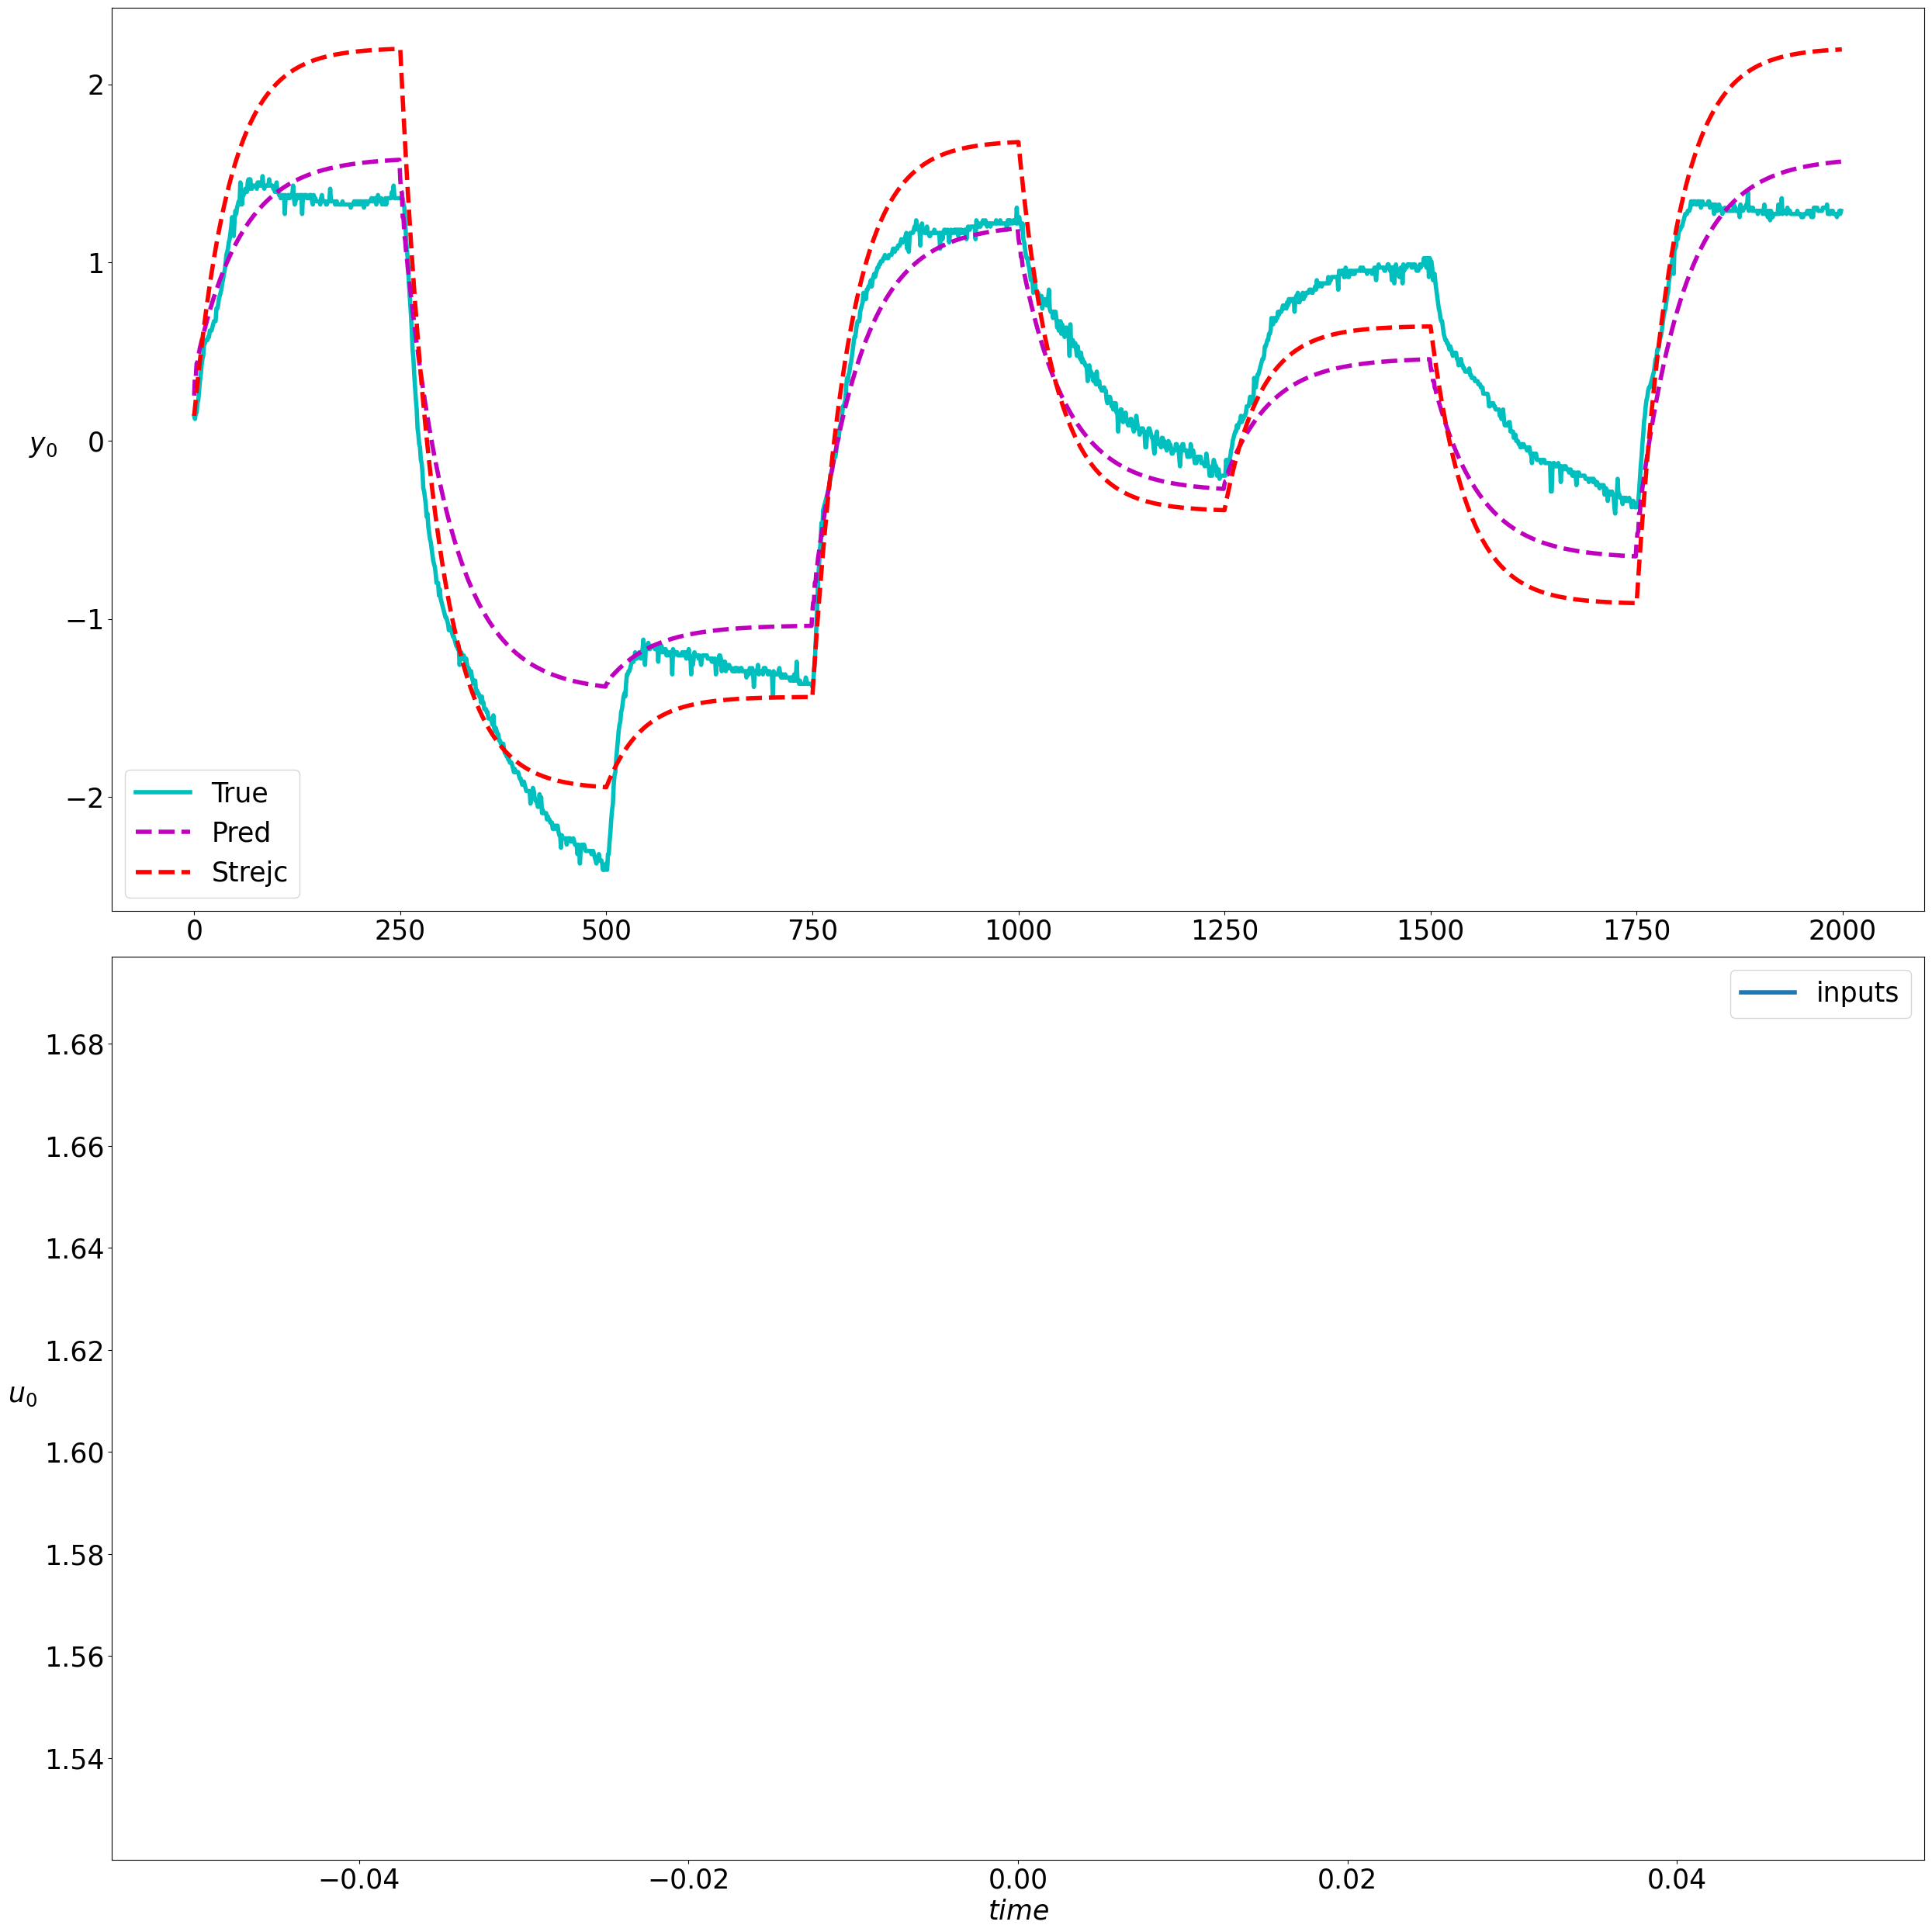

In [ ]:
# plot trajectories
figsize = 25
fig, ax = plt.subplots(nx + nu, figsize=(figsize, figsize))
part = 2000

x_labels = [f'$y_{k}$' for k in range(len(true_traj))]
for row, (t1, t2, t3, t4, label) in enumerate(zip(true_traj, pred_traj, y_strejc.T, baseline_y, x_labels)):
    axe = ax[row]
    axe.set_ylabel(label, rotation=0, labelpad=20, fontsize=figsize)
    axe.plot(t1[:part], 'c', linewidth=4.0, label='True')
    axe.plot(t2[:part], 'm--', linewidth=4.0, label='Pred')
    axe.plot(t3[:part], 'r--', linewidth=4.0, label='Strejc')
    axe.tick_params(labelbottom=False, labelsize=figsize)
axe.tick_params(labelbottom=True, labelsize=figsize)
axe.legend(fontsize=figsize)

u_labels = [f'$u_{k}$' for k in range(1)]
for row, (u, label) in enumerate(zip(input_traj, u_labels)):
    axe = ax[1]# ax[row+nx]
    axe.plot(u[:part].T, linewidth=4.0, label='inputs')
    axe.legend(fontsize=figsize)
    axe.set_ylabel(label, rotation=0, labelpad=20, fontsize=figsize)
    axe.tick_params(labelbottom=True, labelsize=figsize)

ax[-1].set_xlabel('$time$', fontsize=figsize)
plt.tight_layout()

In [ ]:
true_traj[0]

array([0.13969944, 0.12200621, 0.1573927 , ..., 1.2897602 , 1.272067  ,
       1.2897602 ], dtype=float32)

In [ ]:
# part = 300
# jump = 10*part-part

# xs = scaler.inverse_transform([[0]])
# x0 = scaler.inverse_transform([true_traj[:,jump]])
# input_traj = scalerU.inverse_transform(test_data['U'][:,jump:jump+part].detach().numpy()[0])-50
# y_strejc = np.zeros((nx, part+1))
# y_strejc[:, 0] = x0-xs#x0
# for i in range(part):
#     y_strejc[:,i+1] = A_d @ y_strejc[:,i] + B_d @ input_traj[i]
# y_strejc = scaler.transform((y_strejc+xs).T)  


# # plot trajectories
# figsize = 25
# fig, ax = plt.subplots(nx + nu, figsize=(figsize, figsize))


# x_labels = [f'$y_{k}$' for k in range(len(true_traj))]
# for row, (t1, t2, t3, label) in enumerate(zip(true_traj, pred_traj, y_strejc.T, x_labels)):
#     axe = ax[row]
#     axe.set_ylabel(label, rotation=0, labelpad=20, fontsize=figsize)
#     axe.plot(t1[jump:jump+part], 'c', linewidth=4.0, label='True')
#     axe.plot(t2[jump:jump+part], 'm--', linewidth=4.0, label='Pred')
#     axe.plot(t3[:part], 'r--', linewidth=4.0, label='Strejc')
#     axe.tick_params(labelbottom=False, labelsize=figsize)
# axe.tick_params(labelbottom=True, labelsize=figsize)
# axe.legend(fontsize=figsize)



In [ ]:
A = K.weight.detach().numpy()
B = f_u.weight.detach().numpy()
C = f_y_inv.weight.detach().numpy()
D = np.zeros((ny, nu))
""" 
np.save('./data/A_wC_all.npy', A)
np.save('./data/B_wC_all.npy', B)
np.save('./data/C_wC_all.npy', C)
np.save('./data/D_wC_all.npy', D) """


" \nnp.save('./data/A_wC_all.npy', A)\nnp.save('./data/B_wC_all.npy', B)\nnp.save('./data/C_wC_all.npy', C)\nnp.save('./data/D_wC_all.npy', D) "